<a href="https://colab.research.google.com/github/ColeMitnik/ColeMitnik/blob/main/FINAL_YEAR_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Train Data:
             timestamp transaction_id  sender_number  receiver_number  \
0  2024-12-24 13:53:24     TCS7YZ7ETQ   254710816588     254790073561   
1  2025-03-05 13:40:30     TCSXLZA2DR   254765215971     254789330449   
2  2025-01-02 19:17:59     TCSJI7IE9H   254730313330     254716958524   
3  2024-12-04 06:36:32     TCS5DBAEO2   254736292459     254775370041   
4  2025-03-19 14:28:00     TCSBKABL1Y   254735264259     254730611002   

    transaction_type  amount  balance_before  balance_after location  \
0           Withdraw   23342          100914          77572    Narok   
1  Pochi La Biashara  155676          612056         767732   Nakuru   
2           Withdraw   34120          130772          96652  Nairobi   
3           Withdraw    1846            7017           5171   Kitale   
4          Buy Goods   11589           25943          14354  Kericho   

   hour_of_day  ...  velocity_1h  velocity_6h  velocity_24h  \
0           13  ...            1            1        

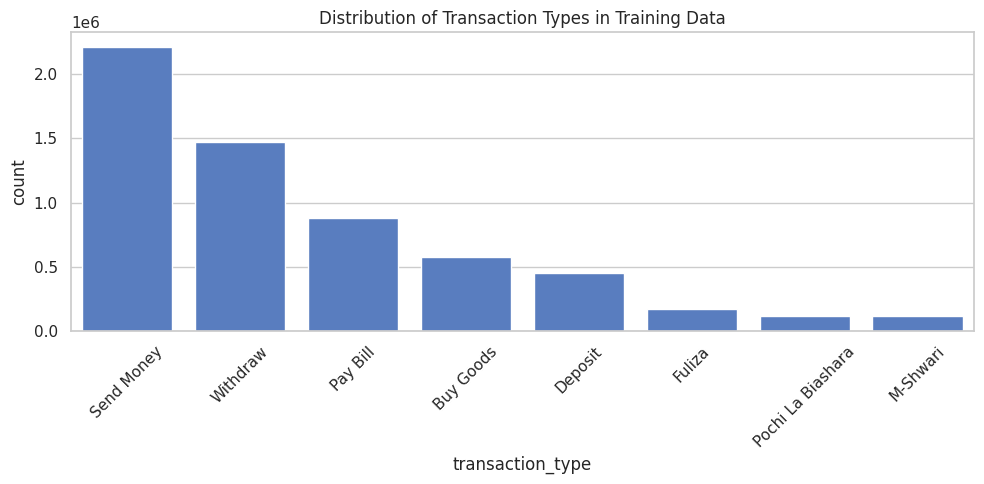

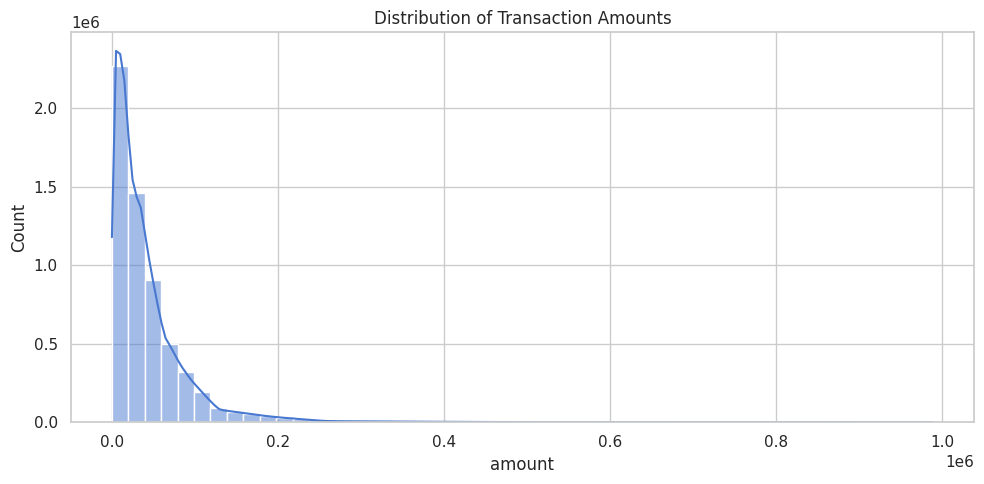

In [3]:
# 📌 CHUNK 1: DATA LOADING & EXPLORATION

# STEP 1: Install required packages (if not installed)
!pip install pandas matplotlib seaborn

# STEP 2: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set up visual style
sns.set(style='whitegrid', palette='muted')

# STEP 3: Load datasets (upload to Colab first or use paths)
train_df = pd.read_csv('/content/final_transactions.csv')
test_df = pd.read_csv('/content/final_batch_test_dataset.csv')
stream_df = pd.read_csv('/content/final_streaming_test_dataset.csv')

# STEP 4: Preview data
print("Train Data:")
print(train_df.head(), "\n")

print("Test Data:")
print(test_df.head(), "\n")

print("Streaming Data:")
print(stream_df.head(), "\n")

# STEP 5: Check structure & compare columns
print("Train Columns:", train_df.columns.tolist())
print("Test Columns:", test_df.columns.tolist())
print("Stream Columns:", stream_df.columns.tolist())

# STEP 6: Check for missing values
print("Missing in Train:\n", train_df.isnull().sum(), "\n")
print("Missing in Test:\n", test_df.isnull().sum(), "\n")
print("Missing in Stream:\n", stream_df.isnull().sum(), "\n")

# STEP 7: Basic EDA
# Let's say there's a 'TransactionType' and 'Amount' column — adjust accordingly

# Visual 1: Transaction type distribution
plt.figure(figsize=(10,5))
sns.countplot(data=train_df, x='transaction_type', order=train_df['transaction_type'].value_counts().index)
plt.title("Distribution of Transaction Types in Training Data")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visual 2: Amount distribution
plt.figure(figsize=(10,5))
sns.histplot(train_df['amount'], bins=50, kde=True)
plt.title("Distribution of Transaction Amounts")
plt.tight_layout()
plt.show()


In [1]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

print("🔄 Loading dataset...")

# Load dataset
df = pd.read_csv('/content/final_transactions.csv')

# 🧹 Basic Cleaning
print("🧼 Cleaning data...")
df.dropna(inplace=True)  # Remove missing values
df = df[df['amount'] > 0]  # Remove zero/negative amounts if any

# Handle outliers (optional: clip amounts at 99th percentile)
q99 = df['amount'].quantile(0.99)
df['amount'] = np.clip(df['amount'], 0, q99)

# Encode 'transaction_type'
print("🔠 Encoding categorical features...")
le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['transaction_type'])

# Feature selection
features = ['amount', 'type_encoded']
X = df[features]
y = df['isFraud']

# Split data
print("🔀 Splitting train/test...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

# Train model
print("🌲 Training Random Forest...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
print("\n📊 Classification Report:")
print(classification_report(y_test, model.predict(X_test)))
print("\n🧾 Confusion Matrix:")
print(confusion_matrix(y_test, model.predict(X_test)))

# Save models
print("💾 Saving model and encoders...")
root_folder = "FDS SYSTEM FINAL"
model_folder = os.path.join(root_folder, "models")
os.makedirs(model_folder, exist_ok=True)

joblib.dump(model, os.path.join(model_folder, "fraud_model.pkl"))
joblib.dump(le, os.path.join(model_folder, "label_encoder.pkl"))
joblib.dump(features, os.path.join(model_folder, "model_features.pkl"))

print(f"✅ All files saved in: {model_folder}")


🔄 Loading dataset...
🧼 Cleaning data...
🔠 Encoding categorical features...
🔀 Splitting train/test...
🌲 Training Random Forest...

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96   1670943
           1       0.13      0.02      0.04    129057

    accuracy                           0.92   1800000
   macro avg       0.53      0.51      0.50   1800000
weighted avg       0.87      0.92      0.89   1800000


🧾 Confusion Matrix:
[[1650067   20876]
 [ 125978    3079]]
💾 Saving model and encoders...
✅ All files saved in: FDS SYSTEM FINAL/models


In [3]:
import shutil
from google.colab import files
from datetime import datetime

# 🕒 Create timestamp
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
zip_name = f"FDS_SYSTEM_FINAL_{timestamp}"

# 📦 Zip the folder with timestamped name
shutil.make_archive(zip_name, 'zip', "FDS SYSTEM FINAL")

# ⬇️ Trigger download
files.download(f"{zip_name}.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import pandas as pd
import numpy as np
import joblib
import os
import shutil
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import files

# 📥 Load full dataset
print("🔄 Loading full dataset...")
df = pd.read_csv('/content/final_transactions.csv')

# 🧼 Clean and encode
print("🧼 Cleaning and encoding...")
df.dropna(inplace=True)
le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['transaction_type'])

# ⚖️ Balance classes (fraud : non-fraud = 1 : 3)
print("⚖️ Balancing the classes...")
fraud = df[df['isFraud'] == 1]
non_fraud = df[df['isFraud'] == 0].sample(n=len(fraud)*3, random_state=42)
df_balanced = pd.concat([fraud, non_fraud]).sample(frac=1, random_state=42)

# ✅ Select features
features = ['amount', 'type_encoded']
X = df_balanced[features]
y = df_balanced['isFraud']

# 🔀 Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# 🌲 Train model
print("🌲 Training balanced Random Forest...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 📊 Evaluate
print("📊 Classification Report:")
print(classification_report(y_test, model.predict(X_test)))
print("🧾 Confusion Matrix:")
print(confusion_matrix(y_test, model.predict(X_test)))

# 💾 Save model & encoder
root_folder = "FDS SYSTEM FINAL"
model_folder = os.path.join(root_folder, "models_balanced")
os.makedirs(model_folder, exist_ok=True)

joblib.dump(model, os.path.join(model_folder, "fraud_model.pkl"))
joblib.dump(le, os.path.join(model_folder, "label_encoder.pkl"))
joblib.dump(features, os.path.join(model_folder, "model_features.pkl"))
print("✅ Balanced model saved in:", model_folder)

# 🗜️ Zip and download just the balanced model
print("📦 Zipping balanced model folder...")
shutil.make_archive("FDS_SYSTEM_FINAL_BALANCED", 'zip', model_folder)
files.download("FDS_SYSTEM_FINAL_BALANCED.zip")

# 🗜️ Zip and download full FDS SYSTEM FINAL folder (backup)
print("📦 Zipping full project folder...")
shutil.make_archive("FDS_SYSTEM_FINAL_ALL", 'zip', root_folder)
files.download("FDS_SYSTEM_FINAL_ALL.zip")

print("🎉 All done. Files saved and downloaded!")


🔄 Loading full dataset...
🧼 Cleaning and encoding...
⚖️ Balancing the classes...
🌲 Training balanced Random Forest...
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.86      0.81    387170
           1       0.30      0.19      0.23    129057

    accuracy                           0.69    516227
   macro avg       0.53      0.52      0.52    516227
weighted avg       0.65      0.69      0.66    516227

🧾 Confusion Matrix:
[[332093  55077]
 [105070  23987]]
✅ Balanced model saved in: FDS SYSTEM FINAL/models_balanced
📦 Zipping balanced model folder...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 Zipping full project folder...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🎉 All done. Files saved and downloaded!


In [3]:
import pandas as pd
import joblib
import time
import os

# 📁 Load saved model, label encoder, and features
model_path = "FDS SYSTEM FINAL/models_balanced/fraud_model.pkl"
encoder_path = "FDS SYSTEM FINAL/models_balanced/label_encoder.pkl"
features_path = "FDS SYSTEM FINAL/models_balanced/model_features.pkl"

print("🔄 Loading saved model and tools...")
model = joblib.load(model_path)
le = joblib.load(encoder_path)
features = joblib.load(features_path)

# 1️⃣ Load final_test.csv and predict
print("\n📄 Loading test set...")
test_df = pd.read_csv("/content/final_batch_test_dataset.csv")
test_df.dropna(inplace=True)
test_df['type_encoded'] = le.transform(test_df['transaction_type'])
X_test = test_df[features]

print("\n🧠 Predicting on test set...")
test_df['prediction'] = model.predict(X_test)

# Show a few predictions
print("\n🔍 Sample predictions from final_test.csv:")
print(test_df[['transaction_type', 'amount', 'prediction']].head(10))


# 2️⃣ Stream from final_streaming.csv (real-time sim)
print("\n🌐 Starting transaction stream...")
stream_df = pd.read_csv("/content/final_streaming_test_dataset.csv")
stream_df.dropna(inplace=True)
stream_df['type_encoded'] = le.transform(stream_df['transaction_type'])

for i, row in stream_df.iterrows():
    x_input = row[features].values.reshape(1, -1)
    prediction = model.predict(x_input)[0]
    status = "🚨 FRAUD" if prediction == 1 else "✅ Legit"

    print(f"🧾 Transaction {i+1}: {row['transaction_type']} | Ksh {row['amount']} → {status}")

    time.sleep(0.5)  # Optional delay for realism, reduce to 0.1 or 0 to speed up

    if i >= 19:  # Show only first 20 for brevity
        break


🔄 Loading saved model and tools...

📄 Loading test set...

🧠 Predicting on test set...

🔍 Sample predictions from final_test.csv:
  transaction_type  amount  prediction
0        Buy Goods   39194           1
1           Fuliza   45621           1
2         Withdraw   24572           0
3       Send Money   88025           1
4         Withdraw    2966           1
5           Fuliza   20899           0
6       Send Money   72297           1
7        Buy Goods   12237           0
8       Send Money   60778           0
9        Buy Goods   16711           0

🌐 Starting transaction stream...
🧾 Transaction 1: Send Money | Ksh 168148 → 🚨 FRAUD


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


🧾 Transaction 2: Send Money | Ksh 959 → ✅ Legit


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


🧾 Transaction 3: Send Money | Ksh 23290 → ✅ Legit


...

🧾 Transaction 18: Pochi La Biashara | Ksh 158532 → 🚨 FRAUD


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


🧾 Transaction 19: Withdraw | Ksh 7462 → ✅ Legit


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


🧾 Transaction 20: Withdraw | Ksh 9287 → ✅ Legit


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load your full dataset (same one you used before training)
df = pd.read_csv("/content/final_transactions.csv")  # Replace with actual file name

# Prepare features and target
X = df[["transaction_type", "amount"]]
y = df["is_fraud"]

# Encode the transaction_type (same encoding you used during training)
le = LabelEncoder()
X["transaction_type"] = le.fit_transform(X["transaction_type"])

# Split again just to recover the test set — this won’t retrain
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


KeyError: 'is_fraud'